In [1]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Activation, Dense, BatchNormalization, concatenate, Dropout, Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D, Input, Reshape
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import SpatialDropout2D
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam, RMSprop
import numpy as np
import pandas as pd
import glob
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import cv2
%matplotlib inline
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from warnings import filterwarnings
from tensorflow.keras.models import load_model
import itertools 
filterwarnings('ignore')
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [4]:

# from tensorflow.keras.mixed_precision import experimental as mixed_precision
# policy = mixed_precision.Policy('mixed_float16')
# mixed_precision.set_policy(policy)
# print('Compute dtype: %s' % policy.compute_dtype)
# print('Variable dtype: %s' % policy.variable_dtype)


In [29]:
train_dir ="train"
val_dir = "val"
test_dir="test"


In [6]:
import tensorflow as tf
import numpy as np
import os
import random


def set_seed(seed):
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)


seed = 101
set_seed(seed)

In [7]:
model1 = VGG16(include_top=False,input_shape=(224, 224,3), weights='imagenet')
input_shape = (224, 224)

In [8]:
datagen_train = ImageDataGenerator(rescale=1./255,
                                  width_shift_range=0.1,
                                  height_shift_range=0.1,
                                  horizontal_flip=True,
                                  vertical_flip=False)



datagen_test = ImageDataGenerator(rescale=1./255)

datagen_val=ImageDataGenerator(rescale=1./255)

batch_size = 20
generator_train = datagen_train.flow_from_directory(directory=train_dir,
                                                    target_size=input_shape,
                                                    batch_size=batch_size,  
                                                    class_mode='categorical',
                                                    shuffle=True)

generator_val = datagen_val.flow_from_directory(directory=val_dir,
                                                  target_size=input_shape,
                                                  batch_size=batch_size,
                                                class_mode='categorical',
                                                  shuffle=True)
generator_test=datagen_test.flow_from_directory(directory=test_dir,
                                                  target_size=input_shape,
                                                 batch_size=batch_size,
                                                class_mode='categorical',
                                                 shuffle=False)

Found 3248 images belonging to 4 classes.
Found 409 images belonging to 4 classes.
Found 405 images belonging to 4 classes.


In [9]:
len(model1.layers)

19

In [10]:
def print_layer_trainable():
    for layer in model1.layers[:-1]:
        layer.trainable=False
        print("{0}:\t{1}".format(layer.trainable, layer.name))


print_layer_trainable()

False:	input_1
False:	block1_conv1
False:	block1_conv2
False:	block1_pool
False:	block2_conv1
False:	block2_conv2
False:	block2_pool
False:	block3_conv1
False:	block3_conv2
False:	block3_conv3
False:	block3_pool
False:	block4_conv1
False:	block4_conv2
False:	block4_conv3
False:	block4_pool
False:	block5_conv1
False:	block5_conv2
False:	block5_conv3


In [11]:
headModel = model1.output
headModel = layers.Flatten()(headModel)
#headModel = Dense(1024, activation="relu")(headModel)
headModel = Dense(512, activation="relu", )(headModel)
headModel = Dropout(0.4)(headModel)
headModel = Dense(4, activation="softmax")(headModel)
model = Model(inputs=model1.input, outputs=headModel)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [12]:
optimizer = Adam(lr=1e-4)
loss = 'categorical_crossentropy'
metrics = ['accuracy','Precision','Recall']


model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

epochs = 25

steps_per_epoch = generator_train.n / batch_size
steps_test = generator_test.n / batch_size

#steps_per_epoch = 20
# steps_test = 50
early_stop = EarlyStopping(patience=2)
history = model.fit_generator(generator=generator_train,
                              epochs=epochs,
                              steps_per_epoch=steps_per_epoch,
                              validation_data=generator_val,
                              validation_steps=steps_test
                              
                             )


Epoch 1/25
162/162 [==============================] - 28s 147ms/step - loss: 0.4314 - accuracy: 0.8307 - precision: 0.8547 - recall: 0.8079 - val_loss: 0.2315 - val_accuracy: 0.8998 - val_precision: 0.8998 - val_recall: 0.8998
Epoch 2/25
162/162 [==============================] - 22s 136ms/step - loss: 0.2310 - accuracy: 0.9036 - precision: 0.9073 - recall: 0.9006 - val_loss: 0.1241 - val_accuracy: 0.9535 - val_precision: 0.9559 - val_recall: 0.9535
Epoch 3/25
162/162 [==============================] - 22s 136ms/step - loss: 0.1734 - accuracy: 0.9320 - precision: 0.9344 - recall: 0.9301 - val_loss: 0.1018 - val_accuracy: 0.9707 - val_precision: 0.9707 - val_recall: 0.9707
Epoch 4/25
162/162 [==============================] - 23s 141ms/step - loss: 0.1506 - accuracy: 0.9400 - precision: 0.9411 - recall: 0.9393 - val_loss: 0.1125 - val_accuracy: 0.9535 - val_precision: 0.9535 - val_recall: 0.9535
Epoch 5/25
162/162 [==============================] - 22s 137ms/step - loss: 0.1379 - accura

In [14]:
model.save("VGG16.h5")

In [15]:
#Get the accuracy score

train_score = model.evaluate_generator(generator_train)



print("[INFO] accuracy: {:.2f}%".format(train_score[1] * 100)) 

print("[INFO] Loss: {:.2f}%".format(train_score[0] * 100)) 

[INFO] accuracy: 97.81%
[INFO] Loss: 5.27%


In [16]:
#Get the accuracy score

test_score = model.evaluate_generator(generator_test)



print("[INFO] accuracy: {:.2f}%".format(test_score[1] * 100)) 

print("[INFO] Loss: {:.2f}%".format(test_score[0] * 100)) 

[INFO] accuracy: 97.78%
[INFO] Loss: 4.83%


In [17]:
classes=list(generator_train.class_indices.keys())
class_count=len(classes)
print(class_count)
li=[1,2,3,4]

4


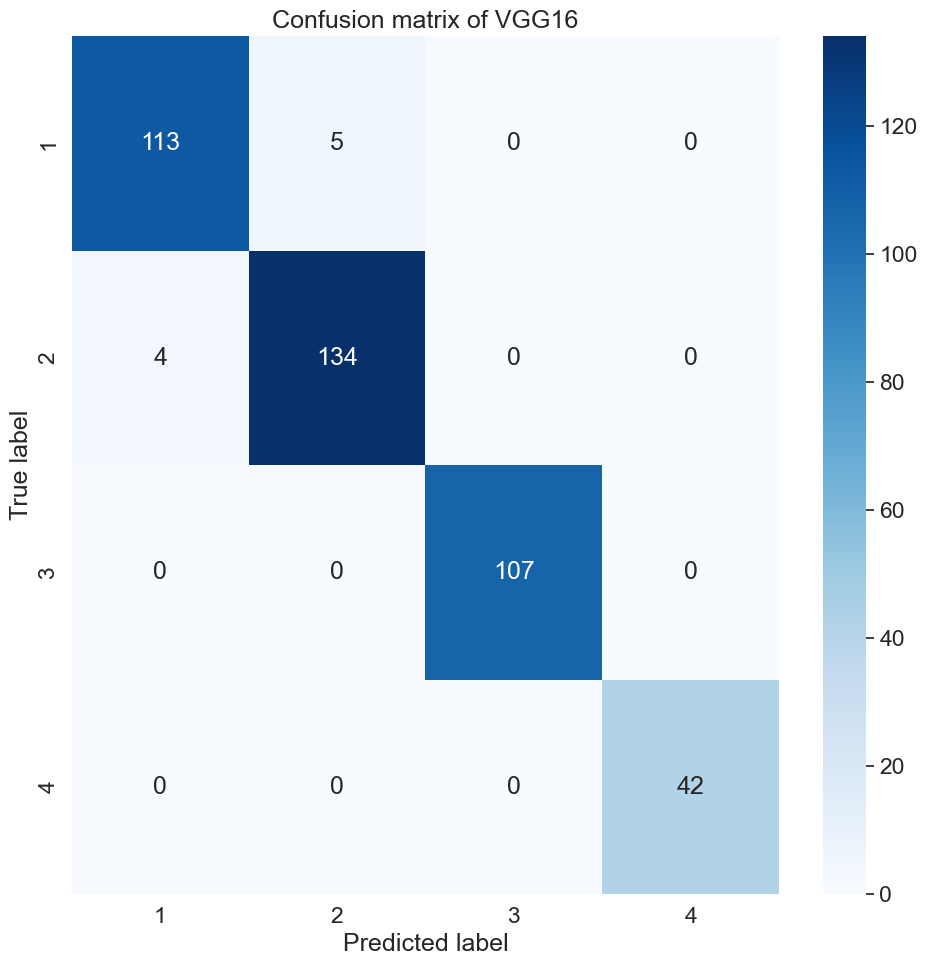

In [18]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
Y_pred = model.predict_generator(generator_test)
y_pred = np.argmax(Y_pred, axis=1)
array = confusion_matrix(generator_test.classes, y_pred)
df_cm = pd.DataFrame(array, index =li,
                  columns = li)
plt.figure(figsize=(10,10))
sn.set(font_scale=1.5)
sn.heatmap(df_cm, annot=True, cmap='Blues', fmt='g')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix of VGG16')
plt.tight_layout()
plt.savefig('VGG16_confusion',dpi=200); 
plt.show()

In [19]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
print(accuracy_score(generator_test.classes, y_pred))

0.9777777777777777


In [20]:
target_names = []

for key in generator_train.class_indices:

    target_names.append(key)



print(target_names)

['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']


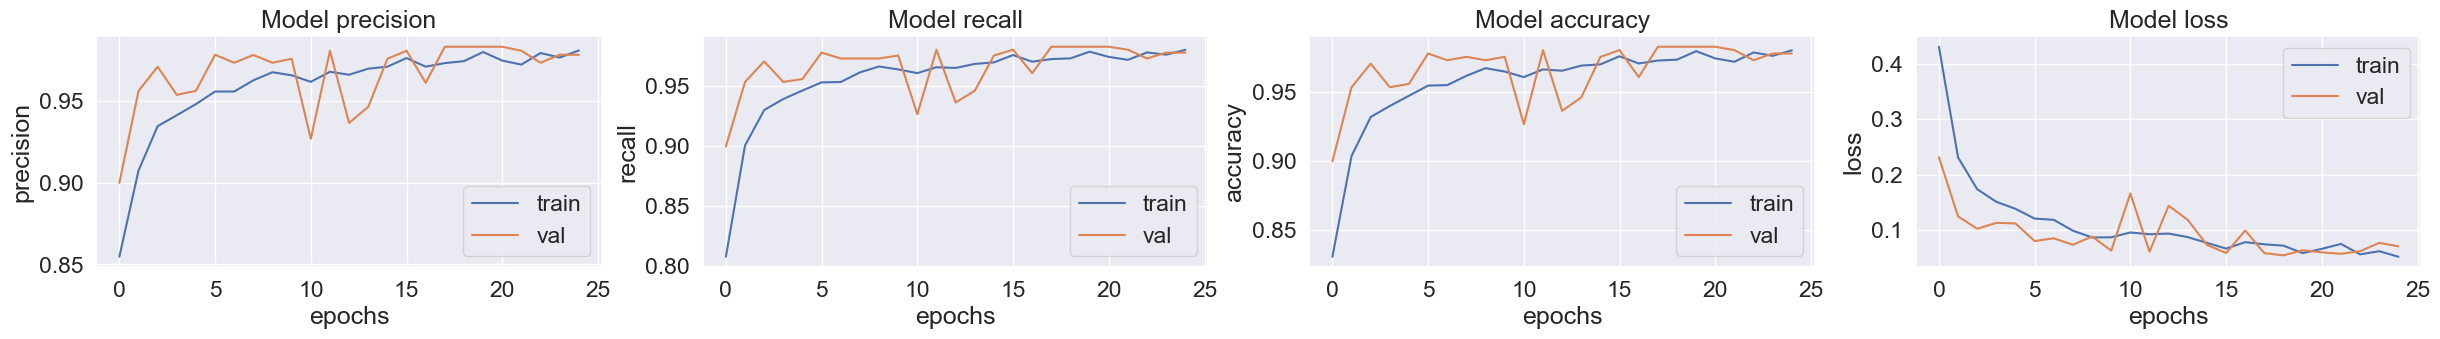

In [21]:
fig, ax = plt.subplots(1, 4, figsize=(30, 3))
ax = ax.ravel()

for i, met in enumerate(['precision', 'recall','accuracy',  'loss']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].legend(['train', 'val'])

In [22]:
preds = model.predict_generator(generator_test)
print(preds)

[[9.99885678e-01 1.14340124e-04 9.46782652e-09 2.33734578e-08]
 [8.45972240e-01 1.53644800e-01 6.87029589e-09 3.83011356e-04]
 [2.66075581e-01 7.33924389e-01 6.53883774e-08 1.84010869e-08]
 ...
 [2.82430541e-08 6.90675206e-09 8.85888748e-03 9.91141081e-01]
 [3.66396300e-08 6.22036334e-09 2.03769204e-07 9.99999762e-01]
 [6.73251510e-10 1.45827983e-09 4.21970459e-09 1.00000000e+00]]


In [23]:
print(classification_report(generator_test.classes, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       118
           1       0.96      0.97      0.97       138
           2       1.00      1.00      1.00       107
           3       1.00      1.00      1.00        42

    accuracy                           0.98       405
   macro avg       0.98      0.98      0.98       405
weighted avg       0.98      0.98      0.98       405



In [24]:
predicted_class_indices=np.argmax(preds,axis=1)
a=0
b=0
for x in predicted_class_indices:
    if x==0:
        a+=1
    else:
        b+=1
print(a," ",b)

117   288


In [25]:
predicted_class_indices

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

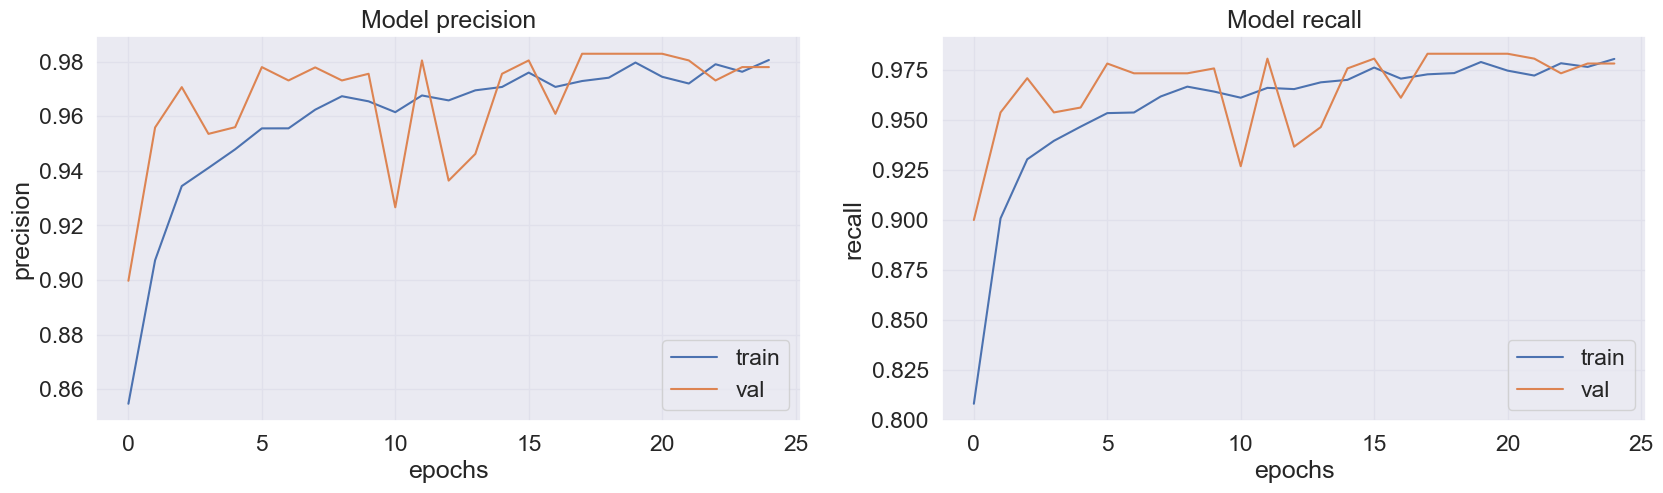

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax = ax.ravel()

for i, met in enumerate(['precision', 'recall']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].grid(color = '#e0e0eb')
    ax[i].legend(['train', 'val'])

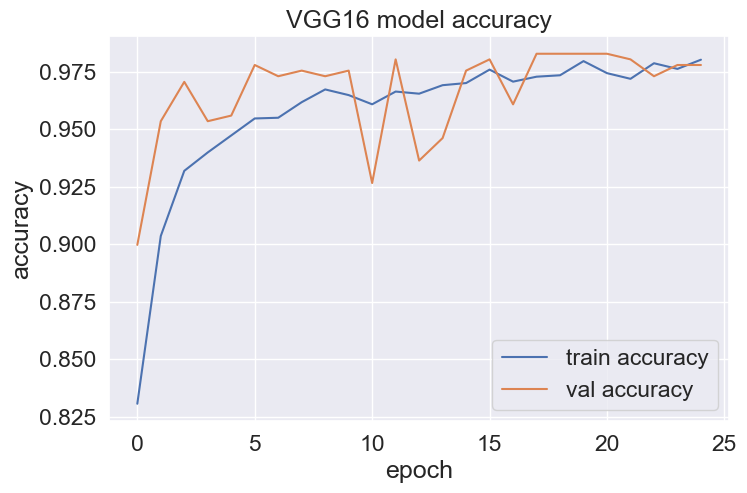

In [27]:

plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.set_facecolor("#eaeaf2")
plt.plot(history.history['accuracy'],label="train accuracy")
plt.plot(history.history['val_accuracy'],label="val accuracy")
plt.title('VGG16 model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.grid(color = 'w')
plt.savefig('VGG16_accuracy',dpi=200); 
plt.show()


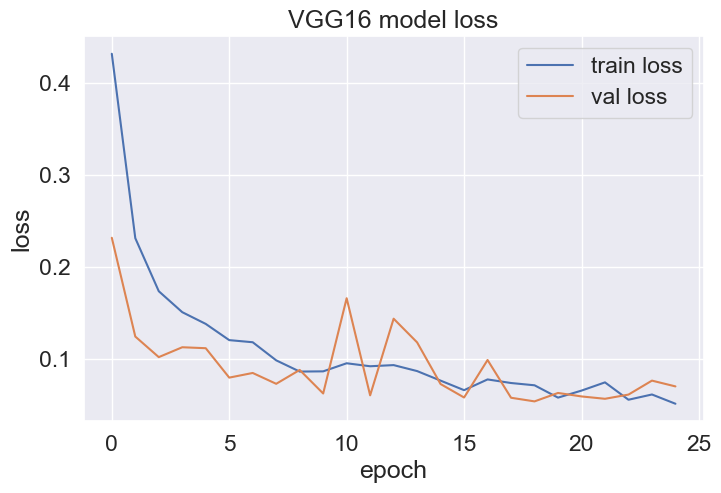

In [28]:
plt.figure(figsize=(8, 5))

ax = plt.axes()
ax.set_facecolor("#eaeaf2")
plt.plot(history.history['loss'],label="train loss")
plt.plot(history.history['val_loss'],label="val loss")
plt.title('VGG16 model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.grid(color = 'w')
plt.savefig('VGG16_loss',dpi=200); 
plt.show()